<a href="https://colab.research.google.com/github/Medrodi/MIIGAIK-Computer-Math/blob/main/10/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22%D0%A1%D0%9A%D0%9C_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9611_%D0%9F%D1%80%D0%B8%D0%BC%D0%B5%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B3%D1%80%D0%B0%D1%84%D0%BE%D0%B2%D1%8B%D1%85_%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%BE%D0%B2_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B8_%D0%BE%D0%BF%D1%82%D0%B8%D0%BC%D0%B0%D0%BB%D1%8C%D0%BD%D0%BE%D0%B3%D0%BE_%D0%BE%D0%B1%D1%8A%D0%B5%D0%B7%D0%B4%D0%B0_%D1%82%D0%BE%D1%87%D0%B5%D0%BA_%D0%BD%D0%B0_%D1%80%D0%B5%D0%B0%D0%BB%D1%8C%D0%BD%D0%BE%D0%B9_%D0%B4%D0%BE%D1%80%D0%BE%D0%B6%D0%BD%D0%BE%D0%B9_%D1%81%D0%B5%D1%82%D0%B8_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №11. Применение графовых алгоритмов для решения задачи оптимального объезда точек на реальной дорожной сети**

## **1. Введение**

### **1.1. Постановка задачи**

Рассмотрим задачу курьерской службы: есть склад (депо) и несколько адресов доставки. Курьер должен объехать все адреса и вернуться на склад. В каком порядке посещать адреса, чтобы минимизировать общий путь (или время, или выбирать более комфортные дороги)?

Для решения этой задачи необходимо:
1. Получить реальную дорожную сеть города в виде графа
2. Вычислить кратчайшие расстояния между всеми точками доставки
3. Найти оптимальный порядок их посещения
4. Восстановить полный маршрут для отображения на карте

### **1.2. Связь с теорией**

В работе применяются:
- Загрузка графа из OpenStreetMap (раздел 3 пособия)
- Разреженные матрицы CSR (раздел 2.2–2.3 пособия)
- Алгоритм Дейкстры для поиска кратчайших путей (раздел 2.5 пособия)
- Сравнение производительности SciPy и NetworkX (раздел 2.6 пособия)

---

## **2. Теоретические сведения**

### **2.1. Задача коммивояжёра (TSP)**

**Формулировка:** Дан полный взвешенный граф с N вершинами. Найти гамильтонов цикл (цикл, проходящий через каждую вершину ровно один раз) минимального веса.

**Применительно к нашей задаче:**
- Вершины — точки доставки (включая депо)
- Вес ребра — кратчайшее расстояние между точками по дорожной сети
- Цикл — маршрут курьера

**Сложность:** TSP является NP-трудной задачей. Для N точек (с фиксированным началом) существует (N-1)!/2 различных маршрутов:

| N | Маршрутов | Время перебора |
|---|-----------|----------------|
| 5 | 12 | мгновенно |
| 8 | 2 520 | мгновенно |
| 10 | 181 440 | < 1 сек |
| 12 | 19 958 400 | ~10 сек |
| 15 | 43 млрд | часы |

### **2.2. Алгоритмы решения TSP**

#### **Полный перебор**

Гарантирует оптимальное решение, но применим только для малого N (до 10-12 точек).

**Идея:** Перебрать все возможные порядки посещения, для каждого вычислить суммарную длину, выбрать минимальный.

**Пример для 4 точек (депо = 0):**

```
Матрица расстояний:
     0    1    2    3
0 [  0, 10, 15, 20 ]
1 [ 10,  0, 35, 25 ]
2 [ 15, 35,  0, 30 ]
3 [ 20, 25, 30,  0 ]

Перебор перестановок [1, 2, 3]:
  0 → 1 → 2 → 3 → 0: 10 + 35 + 30 + 20 = 95
  0 → 1 → 3 → 2 → 0: 10 + 25 + 30 + 15 = 80  ← минимум
  0 → 2 → 1 → 3 → 0: 15 + 35 + 25 + 20 = 95
  0 → 2 → 3 → 1 → 0: 15 + 30 + 25 + 10 = 80  ← минимум
  0 → 3 → 1 → 2 → 0: 20 + 25 + 35 + 15 = 95
  0 → 3 → 2 → 1 → 0: 20 + 30 + 35 + 10 = 95

Оптимальный маршрут: 0 → 1 → 3 → 2 → 0 (длина 80)
```

#### **Жадный алгоритм**

Не гарантирует оптимум, но работает быстро — O(N²).

**Идея:** Из текущей точки всегда переходим в ближайшую непосещённую.

**Пример (та же матрица):**

```
Старт из 0:
1. Из 0: ближайшая — 1 (расстояние 10)
2. Из 1: ближайшая непосещённая — 3 (расстояние 25)
3. Из 3: ближайшая непосещённая — 2 (расстояние 30)
4. Возврат в 0: расстояние 15

Маршрут: 0 → 1 → 3 → 2 → 0
Длина: 10 + 25 + 30 + 15 = 80

В данном случае жадный алгоритм нашёл оптимум, но это не гарантировано.
```

### **2.3. Атрибуты рёбер OpenStreetMap**

Каждый сегмент дороги в OSM имеет атрибуты:

| Атрибут | Описание | Пример значения |
|---------|----------|-----------------|
| `length` | Длина сегмента в метрах | 156.7 |
| `maxspeed` | Разрешённая скорость | "60" или ["60", "40"] |
| `highway` | Тип дороги | "primary", "residential" |
| `name` | Название улицы | "Невский проспект" |
| `oneway` | Односторонняя | True / False |

**Особенности атрибута `maxspeed`:**
- Может быть строкой: `"60"`
- Может быть списком (разные полосы): `["60", "40"]`
- Может отсутствовать

### **2.4. Критерии оптимизации маршрута**

#### **По расстоянию**

Минимизируем суммарную длину пути в метрах.

**Вес ребра** = атрибут `length`

#### **По времени**

Минимизируем время в пути с учётом разрешённой скорости.

**Вес ребра** = время проезда:

```
время (сек) = length (м) / скорость (м/с)
            = length / (maxspeed_kmh / 3.6)
```

Если `maxspeed` отсутствует, используется значение по умолчанию для типа дороги:

| Тип дороги (`highway`) | Скорость по умолчанию (км/ч) |
|------------------------|------------------------------|
| motorway | 110 |
| trunk | 90 |
| primary | 60 |
| secondary | 50 |
| tertiary | 40 |
| residential | 30 |
| living_street | 20 |
| service | 20 |
| unclassified | 30 |

#### **По комфорту**

Предпочитаем широкие магистрали узким улицам.

**Вес ребра** = `length × коэффициент_типа_дороги`

Коэффициент меньше 1 делает дорогу «привлекательнее», больше 1 — «дороже»:

| Тип дороги | Коэффициент |
|------------|-------------|
| motorway | 0.7 |
| trunk | 0.8 |
| primary | 0.85 |
| secondary | 0.9 |
| tertiary | 1.0 |
| residential | 1.2 |
| living_street | 1.4 |
| service | 1.5 |
| unclassified | 1.3 |

**Пример:** Два пути из A в B:
- Через магистраль: 5 км × 0.7 = 3.5 усл.ед.
- Через жилые кварталы: 3 км × 1.2 = 3.6 усл.ед.

Несмотря на бо́льшую длину, маршрут через магистраль будет выбран как более «комфортный».

### **2.5. Алгоритм Дейкстры для поиска кратчайших путей**

Базовое описание алгоритма Дейкстры приведено в **разделе 2.5 пособия**. Здесь рассмотрим его применение к задаче многоточечной маршрутизации.

#### **Суть алгоритма**

Алгоритм Дейкстры находит кратчайшие пути от одной вершины-источника до всех остальных вершин графа. Он работает только с неотрицательными весами рёбер.

**Идея:** Постепенно «разворачиваем» волну от источника, на каждом шаге фиксируя вершину с минимальным известным расстоянием.

**Временная сложность:** O((V + E) log V) при использовании приоритетной очереди, где V — число вершин, E — число рёбер.

#### **Проблема: нужны расстояния между всеми парами точек**

Для решения TSP нам нужна матрица кратчайших расстояний N×N между всеми точками доставки. Наивный подход — запустить алгоритм Дейкстры N раз, по одному разу для каждой точки:



```python
# Наивный подход — N отдельных вызовов
distances = []
predecessors = []
for i in range(n_points):
    dist_i, pred_i = dijkstra(A, indices=point_indices[i])
    distances.append(dist_i)
    predecessors.append(pred_i)
```



Это работает, но неэффективно: каждый вызов заново инициализирует внутренние структуры данных.

#### **Решение: параметр `indices` в SciPy**

Функция `scipy.sparse.csgraph.dijkstra` позволяет передать **список всех источников сразу** в параметр `indices`. Алгоритм выполнит поиск от всех источников за один вызов:



```python
from scipy.sparse.csgraph import dijkstra

# Эффективный подход — один вызов для всех точек
point_indices = [42, 156, 892, 2001, 5500]  # индексы 5 точек в графе

all_distances, all_predecessors = dijkstra(
    csgraph=A,              # CSR-матрица графа
    directed=True,
    indices=point_indices,  # ВСЕ точки одним списком
    return_predecessors=True
)
```



#### **Что возвращает функция**

При вызове с K источниками на графе с V вершинами:

- `all_distances` — матрица размера (K × V)
  - `all_distances[i, j]` — расстояние от источника `point_indices[i]` до вершины `j`
  
- `all_predecessors` — матрица размера (K × V)
  - `all_predecessors[i, j]` — предшественник вершины `j` на кратчайшем пути от источника `point_indices[i]`

#### **Извлечение матрицы расстояний между точками**

Из результата размера (K × V) нужно извлечь подматрицу K×K — расстояния только между нашими точками:



```python
# Пример: 5 точек, граф с 10000 вершин
# all_distances имеет форму (5, 10000)

# Извлекаем матрицу 5×5:
n_points = len(point_indices)
dist_matrix = np.zeros((n_points, n_points))

for i in range(n_points):
    for j in range(n_points):
        # Расстояние от точки i до точки j
        target_vertex = point_indices[j]
        dist_matrix[i, j] = all_distances[i, target_vertex]

# Теперь dist_matrix[i, j] — кратчайшее расстояние
# от точки доставки i до точки доставки j по дорожному графу
```



#### **Сравнение подходов**

| Подход | Вызовов dijkstra | Накладные расходы |
|--------|------------------|-------------------|
| N отдельных вызовов | N | N × инициализация |
| Один вызов с `indices=[...]` | 1 | 1 × инициализация |

На практике один вызов с `indices` работает в 2-3 раза быстрее, чем N отдельных вызовов. В сочетании с преимуществом SciPy над NetworkX (см. **раздел 2.6 пособия**) это даёт значительный выигрыш в производительности.

### **2.6. Восстановление пути через матрицу предшественников**

Подробное описание работы с матрицей предшественников приведено в **разделе 2.5 пособия**.

**Основная идея:** Для каждой вершины `v` матрица хранит её предшественника на кратчайшем пути от источника. Путь восстанавливается «с конца»:

```
Пример: восстановление пути от вершины 0 до вершины 5

predecessors = [-9999, 0, 1, 1, 2, 4]
                  ↑    ↑  ↑  ↑  ↑  ↑
             вершина:  0  1  2  3  4  5

Значение -9999 означает "это источник" или "нет пути".

Восстановление:
  predecessors[5] = 4   → путь заканчивается: ... → 4 → 5
  predecessors[4] = 2   → путь: ... → 2 → 4 → 5
  predecessors[2] = 1   → путь: ... → 1 → 2 → 4 → 5
  predecessors[1] = 0   → путь: 0 → 1 → 2 → 4 → 5

Итоговый путь: [0, 1, 2, 4, 5]
```

При наличии нескольких источников `all_predecessors[i]` содержит предшественников для путей от источника `i`.

---

## **3. Задания**

### **Задание 1. Загрузка и подготовка графа**

Реализуйте функцию, которая:
1. Загружает дорожный граф для заданной области с помощью OSMnx (см. **раздел 3.1 пособия**)
2. Проецирует граф в метрическую систему координат (см. **раздел 3.3 пособия**)
3. Создаёт словари отображения между OSM ID вершин и их индексами в матрице

Функция должна принимать:
- Центральную точку (широта, долгота)
- Радиус области в метрах

Функция должна возвращать:
- Граф NetworkX в исходных координатах WGS84 (для визуализации на карте)
- Граф NetworkX в проекции UTM (для расчётов в метрах)
- Словарь `node_to_idx`: OSM ID → индекс в матрице
- Словарь `idx_to_node`: индекс в матрице → OSM ID

---

In [1]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.2 MB/s eta 0:00:00


In [21]:
import numpy as np                          # импорт библиотеки NumPy для работы с массивами и численными операциями
import scipy.sparse as sp                   # модуль SciPy для разреженных матриц (сокращённо sp)
from scipy.sparse import csr_matrix, coo_matrix  # отдельный импорт форматов разреженных матриц CSR и COO
from scipy.sparse.csgraph import (          # импорт алгоритмов на графах для разреженных матриц
    dijkstra,                               # алгоритм Дейкстры (кратчайшие пути без отрицательных рёбер)
    bellman_ford,                           # алгоритм Беллмана–Форда (кратчайшие пути с отрицательными рёбрами)
    floyd_warshall,                         # алгоритм Флойда–Уоршелла (все пары кратчайших путей)
    johnson,                                # алгоритм Джонсона (эффективно для разреженных графов)
    breadth_first_order,                    # обход графа в ширину (BFS)
    depth_first_order,                      # обход графа в глубину (DFS)
    connected_components,                   # поиск компонент связности в графе
    minimum_spanning_tree,                  # поиск минимального остовного дерева
    maximum_flow,                           # алгоритмы максимального потока
    laplacian,                              # вычисление лапласиана графа
)
import networkx as nx                       # библиотека NetworkX для работы с графами высокого уровня
import matplotlib.pyplot as plt             # matplotlib.pyplot для визуализации (графики, рисунки)
import osmnx as ox
import itertools

In [5]:
ox.settings.log_console = True
ox.settings.use_cache = True

In [6]:
def load_and_prepare_graph(center_point, radius):
  G = ox.graph_from_point(center_point, dist=radius, network_type="drive")
  G_proj = ox.project_graph(G)
  nodes = list(G_proj.nodes())
  node_to_idx = {node: i for i, node in enumerate(nodes)}
  idx_to_node = {i: node for i, node in enumerate(nodes)}

  return G, G_proj, node_to_idx, idx_to_node

Baumanka_cords = (55.7658, 37.6847)
radius = 2000

G, G_proj, node_to_idx, idx_to_node = load_and_prepare_graph(
    center_point=Baumanka_cords, radius=radius
)

print("Вершин в исходном графе G:", len(G.nodes()))
print("Вершин в спроецированном графе G_proj:", len(G_proj.nodes()))
print("Размер словаря node_to_idx:", len(node_to_idx))


Вершин в исходном графе G: 699
Вершин в спроецированном графе G_proj: 699
Размер словаря node_to_idx: 699


---

### **Задание 2. Построение матриц весов**

Реализуйте функцию, которая строит три разреженные CSR-матрицы для разных критериев оптимизации.

**Матрица расстояний:**
- Вес ребра = атрибут `length` (метры)

**Матрица времени:**
- Вес ребра = `length / скорость` (секунды)
- Скорость берётся из атрибута `maxspeed`
- Если `maxspeed` — список, берите первый элемент
- Если `maxspeed` отсутствует или некорректен, используйте значение по умолчанию для типа дороги (атрибут `highway`)
- Не забудьте перевести км/ч в м/с (разделить на 3.6)

**Матрица комфорта:**
- Вес ребра = `length × коэффициент_комфорта`
- Коэффициент зависит от типа дороги (`highway`)

Функция должна принимать:
- Граф NetworkX в проекции UTM

Функция должна возвращать:
- Словарь с тремя CSR-матрицами: `{"distance": ..., "time": ..., "comfort": ...}`
- Словари `node_to_idx` и `idx_to_node`

Процесс построения CSR-матрицы из графа описан в **разделе 2.4 пособия**.

---

In [17]:
default_speed = {
    "motorway": 110,
    "trunk": 90,
    "primary": 60,
    "secondary": 50,
    "tertiary": 40,
    "residential": 30,
    "living_street": 20,
    "service": 20,
    "unclassified": 30,
}

default_comfort_coefs = {
    "motorway": 0.7,
    "trunk": 0.8,
    "primary": 0.85,
    "secondary": 0.9,
    "tertiary": 1.0,
    "residential": 1.2,
    "living_street": 1.4,
    "service": 1.5,
    "unclassified": 1.3,
}

def build_weight_matrices(G_proj):
    nodes = sorted(G_proj.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    idx_to_node = {i: node for i, node in enumerate(nodes)}
    n = len(nodes)

    rows, cols = [], []
    distance_data, time_data, comfort_data = [], [], []

    for u, v, k, data in G_proj.edges(keys=True, data=True):
        rows.append(node_to_idx[u])
        cols.append(node_to_idx[v])

        length = float(data.get("length", 1.0))
        distance_data.append(length)


        highway = data.get('highway')
        if isinstance(highway, list):
            highway = highway[0]

        speed_raw = data.get('maxspeed', default_speed)
        if isinstance(speed_raw, list):
            speed_raw = speed_raw[0]
        try:
            speed_kmh = float(str(speed_raw).split()[0])
        except:
            speed_kmh = 60

        speed_ms = speed_kmh / 3.6
        time_data.append(length / speed_ms if speed_ms > 0 else 0)

        coeff = default_comfort_coefs.get(highway, 1.3)
        comfort_data.append(length * coeff)

    matrices = {
        "distance": csr_matrix((distance_data, (rows, cols)), shape=(n, n)),
        "time": csr_matrix((time_data, (rows, cols)), shape=(n, n)),
        "comfort": csr_matrix((comfort_data, (rows, cols)), shape=(n, n)),
    }

    return matrices, node_to_idx, idx_to_node



matrices, node_to_idx, idx_to_node = build_weight_matrices(G_proj)


for k, m in matrices.items():
    print(f"  Матрица '{k}': размер {m.shape}, элементов {m.nnz}")
    print(f"  Матрица '{k}':\n{matrices[k]}")


  Матрица 'distance': размер (699, 699), элементов 1342
  Матрица 'distance':
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1342 stored elements and shape (699, 699)>
  Coords	Values
  (0, 338)	182.3868778174433
  (0, 619)	262.91565942649873
  (1, 317)	128.0973174090807
  (2, 571)	208.3046759533881
  (3, 670)	12.759060481676315
  (3, 671)	12.355117220833902
  (4, 181)	75.35429165561732
  (4, 182)	202.29811760694622
  (5, 3)	485.8930659888313
  (6, 8)	63.64248390380729
  (7, 488)	189.17567045935772
  (8, 9)	309.6266295748304
  (9, 10)	84.35380265780026
  (9, 242)	43.621815373457736
  (10, 160)	898.6240499433576
  (11, 159)	635.808529694107
  (11, 185)	62.67030305657789
  (12, 92)	51.41889984320572
  (12, 501)	16.618234974921457
  (12, 569)	41.95355816663387
  (13, 483)	23.392658049279145
  (13, 688)	15.103521653896934
  (14, 80)	27.92031002888923
  (15, 181)	194.89003609434656
  (15, 182)	148.403932461327
  :	:
  (683, 156)	7.140637773426874
  (684, 431)	10.8886572902338

---

### **Задание 3. Вычисление кратчайших расстояний между точками доставки**

Реализуйте функцию, которая вычисляет матрицу кратчайших расстояний между N точками доставки с использованием алгоритма Дейкстры.

**Основное требование:** Используйте параметр `indices` функции `scipy.sparse.csgraph.dijkstra`, чтобы вычислить расстояния от всех N точек **за один вызов функции**, а не за N отдельных вызовов в цикле.

Функция должна принимать:
- Разреженную CSR-матрицу весов графа
- Список индексов точек доставки в графе (например, `[42, 156, 892, 2001, 5500]`)

Функция должна возвращать:
- Квадратную матрицу N×N, где элемент `[i, j]` — кратчайшее расстояние от точки `i` до точки `j`
- Матрицу предшественников размера (N × V) для последующего восстановления путей

**Алгоритм:**
1. Вызовите `dijkstra(csgraph=A, indices=point_indices, return_predecessors=True)`
2. Из результата размера (N × V) извлеките подматрицу N×N, содержащую расстояния только между вашими точками

Пример использования `dijkstra` приведён в **разделе 2.5 пособия**.

---

In [20]:
def find_shorter_way(A, point_indices):
      distances, matrix_nv = dijkstra(
        csgraph=A,
        directed=True,
        indices=point_indices,
        return_predecessors=True
      )

      dist_matrix_nn = distances[:, point_indices]

      return dist_matrix_nn, matrix_nv

point = [7, 14, 13, 25, 79]
dist_matrix, preds = find_shorter_way(matrices['time'], point)
print(dist_matrix)
print(f"\n{preds}")

[[  0.         407.13777447 357.21278397 267.73032343          inf]
 [446.48199939   0.         240.80432206 161.09892594          inf]
 [475.05324545  49.9249905    0.         210.4407657           inf]
 [285.38307345 152.40599671 151.92364778   0.                  inf]
 [467.26088824  75.72361144 188.03314824 181.87781479   0.        ]]

[[278 314 667 ... 697 542 296]
 [278 314 667 ... 697 542 296]
 [278 314 667 ... 697 542 296]
 [278 314 667 ... 697 542 296]
 [278 314 667 ... 697 542 296]]


---

### **Задание 4. Решение задачи коммивояжёра**

Реализуйте две функции для решения TSP:

**Функция полного перебора** (для N ≤ 10):
- Принимает матрицу расстояний N×N и индекс начальной точки (депо)
- Перебирает все перестановки остальных точек с помощью `itertools.permutations`*
- Для каждой перестановки вычисляет суммарную длину маршрута (включая возврат в депо)
- Возвращает оптимальный порядок посещения и его длину

**Функция жадного алгоритма** (для N > 10):
- Принимает матрицу расстояний N×N и индекс начальной точки (депо)
- Начинает с депо
- На каждом шаге выбирает ближайшую непосещённую точку
- После посещения всех точек возвращается в депо
- Возвращает порядок посещения и длину маршрута

---

*Подсказка: `itertools.permutations`

Функция `permutations` генерирует все возможные перестановки элементов:

```python
from itertools import permutations

for p in permutations([1, 2, 3]):
    print(p)

# Вывод:
# (1, 2, 3)
# (1, 3, 2)
# (2, 1, 3)
# (2, 3, 1)
# (3, 1, 2)
# (3, 2, 1)
```

Для N элементов генерируется N! перестановок.

---

In [24]:
def solve_tsp_exact(d_matrix, start_idx=0):
    n = len(d_matrix)
    best_path = None
    min_dist = float("inf")

    other_points = [i for i in range(n) if i != start_idx]

    for p in itertools.permutations(other_points):
        current_path = [start_idx] + list(p) + [start_idx]
        current_dist = 0

        for i in range(len(current_path) - 1):
            u_node = current_path[i]
            v_node = current_path[i + 1]
            current_dist += d_matrix[u_node, v_node]

        if current_dist < min_dist:
            min_dist = current_dist
            best_path = current_path

    return best_path, min_dist


def solve_tsp_greedy(d_matrix, start_idx=0):

    n = len(d_matrix)
    visited = [False] * n

    path = [start_idx]
    visited[start_idx] = True
    total_dist = 0

    current_idx = start_idx

    for _ in range(n - 1):
        next_node = None
        min_d = float("inf")

        for neighbor in range(n):
            if not visited[neighbor] and d_matrix[current_idx, neighbor] < min_d:
                min_d = d_matrix[current_idx, neighbor]
                next_node = neighbor

        path.append(next_node)
        visited[next_node] = True
        total_dist += min_d
        current_idx = next_node

    path.append(start_idx)
    total_dist += d_matrix[current_idx, start_idx]

    return path, total_dist


def solve_tsp(d_matrix, start_idx=0):
    n = len(d_matrix)

    if np.isinf(dist_matrix).any():
      dist_matrix[np.isinf(dist_matrix)] = 999999

    if n <= 10:
        return solve_tsp_exact(d_matrix, start_idx)
    else:
        return solve_tsp_greedy(d_matrix, start_idx)


path, total_dist = solve_tsp(dist_matrix, 0)
print(path)
print(total_dist)

[0, 4, 2, 1, 3, 0]
1000683.440138138


---

### **Задание 5. Восстановление полного маршрута**

Реализуйте функцию, которая по порядку посещения точек TSP восстанавливает полный маршрут через все промежуточные вершины дорожного графа.

Функция должна принимать:
- Порядок посещения точек (например, `[0, 3, 1, 2, 0]`)
- Список индексов точек в графе
- Матрицу предшественников из задания 3
- Словарь `idx_to_node`

Функция должна возвращать:
- Список OSM ID всех вершин маршрута (для отрисовки линии на карте)

**Алгоритм:**
1. Для каждой пары последовательных точек в порядке посещения (0→3, 3→1, 1→2, 2→0)
2. Восстановите путь между ними, используя соответствующую строку матрицы предшественников
3. Соедините сегменты в один маршрут, избегая дублирования вершин на стыках
4. Преобразуйте индексы вершин в OSM ID с помощью `idx_to_node`

---

In [ ]:
def reconstruct_full_route(tsp_path, point_indices, matrix_nv, idx_to_node):

    def reconstruct_path_internal(predecessors_row, start, end):
        if predecessors_row[end] == -9999 and start != end:
            return None

        path = [end]
        current = end
        while current != start:
            current = predecessors_row[current]
            if current == -9999:
                return None
            path.append(current)

        return path[::-1]

    full_route_idx = []

    for idx in range(len(tsp_path) - 1):
        start_point_idx = tsp_path[idx]
        end_point_idx = tsp_path[idx + 1]

        start_csr = point_indices[start_point_idx]
        end_csr = point_indices[end_point_idx]

        pred_row = matrix_nv[start_point_idx]

        sub_path = reconstruct_path_internal(pred_row, start_csr, end_csr)

        if sub_path:
            if idx == 0:
                full_route_idx.extend(sub_path)
            else:
                full_route_idx.extend(sub_path[1:])
        else:
            print(
                f"Внимание: не удалось восстановить путь между точками {start_point_idx} и {end_point_idx}"
            )

    full_osm_route = [idx_to_node[i] for i in full_route_idx]

    return full_osm_route



---

### **Задание 6. Настраиваемые веса типов дорог**

Расширьте решение, добавив возможность пользователю задавать собственные коэффициенты комфорта для каждого типа дороги через интерфейс.

Реализуйте функцию пересчёта матрицы комфорта, которая:
- Принимает граф NetworkX и словарь пользовательских коэффициентов
- Возвращает новую CSR-матрицу с пересчитанными весами

**Типы дорог для настройки:**

| Тип (`highway`) | Описание | Коэффициент по умолчанию |
|-----------------|----------|--------------------------|
| motorway | Автомагистраль | 0.7 |
| trunk | Скоростная дорога | 0.8 |
| primary | Главная дорога | 0.85 |
| secondary | Второстепенная дорога | 0.9 |
| tertiary | Местная дорога | 1.0 |
| residential | Жилая улица | 1.2 |
| living_street | Жилая зона | 1.4 |
| service | Служебная дорога | 1.5 |
| unclassified | Неклассифицированная | 1.3 |

Пользователь должен иметь возможность изменить любой коэффициент, после чего маршрут перестраивается с новыми весами.

---

In [ ]:

default_comfort_coefs = {
    "motorway": 0.7,
    "trunk": 0.8,
    "primary": 0.85,
    "secondary": 0.9,
    "tertiary": 1.0,
    "residential": 1.2,
    "living_street": 1.4,
    "service": 1.5,
    "unclassified": 1.3,
}


def recompute_comfort_matrix(G_proj, user_comfort_coeffs):

    nodes = sorted(G_proj.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    n = len(nodes)

    rows, cols = [], []
    comfort_data = []


    for u, v, k, data in G_proj.edges(keys=True, data=True):
        rows.append(node_to_idx[u])
        cols.append(node_to_idx[v])

        length = float(data.get("length", 1.0))

        highway_raw = data.get("highway", "unclassified")
        if isinstance(highway_raw, list):
            highway = highway_raw[0]
        else:
            highway = highway_raw


        coeff = user_comfort_coeffs.get(
            highway, default_comfort_coefs.get(highway, 1.3)
        )

        comfort_data.append(length * coeff)

    new_comfort_matrix = csr_matrix(
        (comfort_data, (rows, cols)), shape=(n, n)
    )

    return new_comfort_matrix

---

## **4. Требования к интерфейсу**

---

**Исходный код заготовки интерфейса доступен по ссылке:** https://github.com/Alexandre77777/GeoRoute_Base

**Ссылка на веб-приложение (заготовку):** https://osm-route.streamlit.app/

---

Создайте веб-приложение на Streamlit со следующими элементами:

### **4.1. Общая структура**

**Ссылка на готовое веб-приложение: https://route-optima.streamlit.app/**

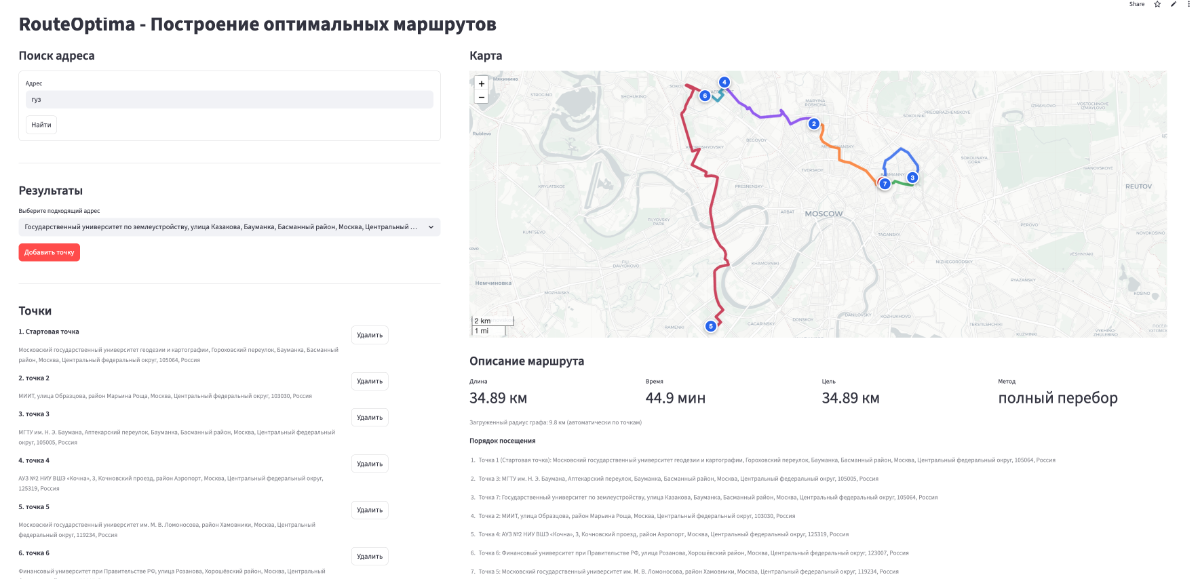

### **4.2. Боковая панель**

**Блок поиска адреса:**
- Текстовое поле для ввода адреса
- Кнопка "Найти"
- Список результатов поиска с кнопками "Добавить" у каждого

**Блок списка точек:**
- Отображение всех добавленных точек (первая — депо)
- Кнопка удаления у каждой точки
- Кнопка "Очистить всё"

**Блок настройки маршрута:**
- Выбор критерия оптимизации (расстояние / время / комфорт)
- Кнопка "Построить маршрут"

**Блок настройки коэффициентов** (для критерия "комфорт"):
- Числовые поля для каждого типа дороги
- Кнопка "Применить коэффициенты"

### **4.3. Основная область**

**Интерактивная карта:**
- Маркеры всех точек доставки (депо выделено особым цветом)
- Линия построенного маршрута
- Всплывающие подсказки при наведении

**Информация о маршруте** (после построения):
- Общая длина в километрах
- Примерное время в минутах
- Порядок посещения точек

### **4.4. Используемые виджеты Streamlit**

**Текстовый ввод:**

In [ ]:
address = st.text_input("Введите адрес")

**Кнопка:**

In [ ]:
if st.button("Найти"):
    # действие

**Выбор из вариантов:**

In [ ]:
criterion = st.radio("Критерий", ["distance", "time", "comfort"])
# или
criterion = st.selectbox("Критерий", ["distance", "time", "comfort"])

**Числовое поле** (для коэффициентов):

In [ ]:
coef = st.number_input(
    label="residential",
    min_value=0.1,
    max_value=5.0,
    value=1.2,
    step=0.1
)

Документация: https://docs.streamlit.io/develop/api-reference/widgets/st.number_input

**Хранение состояния** (для списка точек):

In [ ]:
if "points" not in st.session_state:
    st.session_state.points = []

Документация: https://docs.streamlit.io/develop/api-reference/caching-and-state/st.session_state

**Отображение карты Folium:**

In [ ]:
from streamlit_folium import st_folium

m = folium.Map(location=[59.93, 30.31], zoom_start=12)
st_folium(m, width=700, height=500)

Документация: https://github.com/randyzwitch/streamlit-folium

---

Исходный код заготовки фронтэнда доступен по ссылке: https://github.com/Alexandre77777/GeoRoute_Base